# EV Project - Unsupervised Learning Analysis

- PCA + SVD
- K-means clustering
- Hierarchical clustering
- Side-by-side comparison notes against teammate results

### notes on interpretation: 
**A**=Alex, **G**=Gurpreet, **N**=Naomi

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

In [2]:
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

In [3]:
# Set project working directory
os.chdir(r"C:\\Users\\alexm\\Documents\\GitHub\\SML_group_project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\alexm\Documents\GitHub\SML_group_project


In [4]:
# Load the scaled county-level dataset
my_county_scaled = pd.read_csv('data/county_scaled.csv')
print('county_scaled shape:', my_county_scaled.shape)
display(my_county_scaled.head())

county_scaled shape: (39, 25)


,county,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,total_chargers,level1_chargers,level2_chargers,dc_fast_chargers,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146,0.167054,-0.164494,-0.056726,-0.943417,-0.284265,-0.185346,-0.283009,-0.281631,2.701390,1.016734,-1.114216,-1.056557,-1.189832,-0.650199,-0.354030,-1.817486,0.251486,1.534355
1,ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187,-0.587885,0.589688,-0.825894,-0.531097,-0.302321,-0.185346,-0.277127,-0.463012,-0.849210,-0.369807,-1.047830,-1.038530,-1.017391,-1.403685,-0.354030,-1.146074,-1.099162,-0.357901
2,BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907,-0.033466,0.035825,-0.291918,0.769852,-0.191406,-0.185346,-0.194781,-0.160711,0.334323,-0.468077,0.649723,0.626235,0.710560,0.304856,-0.354030,0.281179,0.527180,-0.688372
3,CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473,1.161181,-1.157625,1.672837,0.035469,-0.101126,0.283529,-0.127139,0.081131,0.349117,0.243146,0.249647,0.307819,0.080535,0.658957,2.363072,0.620363,0.855439,0.797796
4,CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965,-0.215862,0.218038,-0.484569,-0.368438,-0.132080,-0.185346,-0.150667,0.000517,0.351728,0.056492,0.277632,0.257791,0.340796,0.558610,-0.354030,0.522370,0.765017,0.537893


## 1. Data Prep

Use `county_scaled.csv` as the final modeling matrix.

In [5]:
# First column = county label, rest = scaled numeric features
my_county_names = my_county_scaled.iloc[:, 0].copy()
my_all_features = my_county_scaled.iloc[:, 1:].copy()

# Remove duplicated information: if X_log exists, drop raw X
my_log_cols = [c for c in my_all_features.columns if c.endswith('_log')]
my_raw_dupes = [c.replace('_log', '') for c in my_log_cols if c.replace('_log', '') in my_all_features.columns]
my_keep_cols = [c for c in my_all_features.columns if c not in my_raw_dupes]
my_X = my_all_features[my_keep_cols].copy()

print('Dropped raw columns (kept log versions):')
print(my_raw_dupes)
print('\nModel matrix shape:', my_X.shape)
print('\nModel feature columns:')
print(my_X.columns.tolist())

Dropped raw columns (kept log versions):
['total_EV_count', 'BEV_count', 'PHEV_count', 'total_chargers', 'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'chargers_per_1000_EV']

Model matrix shape: (39, 16)

Model feature columns:
['avg_model_year', 'avg_electric_range', 'avg_vehicle_age', 'percent_BEV', 'percent_PHEV', 'BEV_to_PHEV_ratio', 'median_income_2025', 'fast_charger_share', 'total_EV_count_log', 'BEV_count_log', 'PHEV_count_log', 'total_chargers_log', 'level1_chargers_log', 'level2_chargers_log', 'dc_fast_chargers_log', 'chargers_per_1000_EV_log']


## 2. PCA + SVD

### A. PCA

,PC,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.4930,0.4930
1,PC2,0.1898,0.6828
2,PC3,0.1269,0.8097
3,PC4,0.0683,0.8780
4,PC5,0.0527,0.9307
5,PC6,0.0370,0.9677
6,PC7,0.0152,0.9829
7,PC8,0.0099,0.9928
8,PC9,0.0047,0.9974
9,PC10,0.0020,0.9994


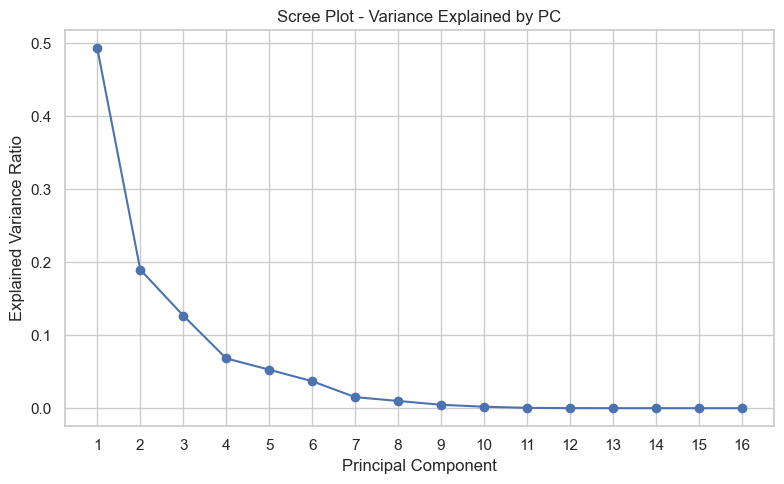

In [6]:
# Fit PCA on all numeric features
my_pca = PCA()
my_pca.fit(my_X)

my_explained = my_pca.explained_variance_ratio_
my_cum_explained = np.cumsum(my_explained)
my_pc_labels = [f'PC{i+1}' for i in range(len(my_explained))]

# Variance table
my_variance_table = pd.DataFrame({
    'PC': my_pc_labels,
    'explained_variance_ratio': my_explained,
    'cumulative_variance_ratio': my_cum_explained
})

# Format only float columns to 4 decimals
float_cols = my_variance_table.select_dtypes(include='float').columns
display(
    my_variance_table.style.format({col: "{:.4f}" for col in float_cols})
)

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(my_explained) + 1), my_explained, marker='o')
plt.title('Scree Plot - Variance Explained by PC')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(my_explained) + 1))
plt.tight_layout()
plt.show()

In [7]:
# PCA loadings (rotation matrix)
my_loadings = pd.DataFrame(
    my_pca.components_.T,
    index=my_X.columns,
    columns=my_pc_labels
)

# PCA scores for counties
my_scores = pd.DataFrame(
    my_pca.transform(my_X),
    columns=my_pc_labels
)
my_scores.insert(0, 'county', my_county_names.values)

print('PCA loadings (first 8 features, first 5 PCs):')
float_cols = my_loadings.select_dtypes(include='float').columns
display(my_loadings.iloc[:8, :5].style.format({col: "{:.4f}" for col in float_cols}))

print('PCA scores (first 10 counties, first 5 PCs):')
float_cols = my_scores.select_dtypes(include='float').columns
display(my_scores[['county'] + my_pc_labels[:5]].head(10).style.format({col: "{:.4f}" for col in float_cols}))

PCA loadings (first 8 features, first 5 PCs):


,PC1,PC2,PC3,PC4,PC5
avg_model_year,0.1403,0.3851,0.2436,-0.4877,-0.0195
avg_electric_range,0.1843,0.4086,-0.2508,0.1695,-0.0234
avg_vehicle_age,-0.1403,-0.3851,-0.2436,0.4877,0.0195
percent_BEV,0.2771,0.2882,-0.1928,0.1454,-0.1000
percent_PHEV,-0.2767,-0.2885,0.1934,-0.1456,0.1017
BEV_to_PHEV_ratio,0.2652,0.2397,-0.2472,0.2982,0.0160
median_income_2025,0.2838,-0.1946,-0.1545,-0.0078,-0.1080
fast_charger_share,0.0355,0.0746,0.5393,0.4594,-0.3121


PCA scores (first 10 counties, first 5 PCs):


,county,PC1,PC2,PC3,PC4,PC5
0,ADAMS,-1.8334,2.4016,2.1386,1.9329,-0.4460
1,ASOTIN,-3.1263,0.0520,-0.8448,-0.5159,0.1161
2,BENTON,1.0864,-0.8077,0.2285,-0.3395,-0.9504
3,CHELAN,2.8341,1.7620,-0.0077,0.9521,1.8228
4,CLALLAM,0.0074,-1.4670,0.7734,0.9852,-0.0188
5,CLARK,3.2603,-1.1005,0.5343,-0.6238,-1.1659
6,COLUMBIA,-1.2714,4.3674,-0.5190,1.9448,1.6017
7,COWLITZ,0.3578,0.4187,1.1873,0.4135,-1.0861
8,DOUGLAS,-0.3197,1.2472,-1.4279,0.1007,-0.6466
9,FERRY,-1.9944,3.6320,-3.1560,0.0515,-0.9958


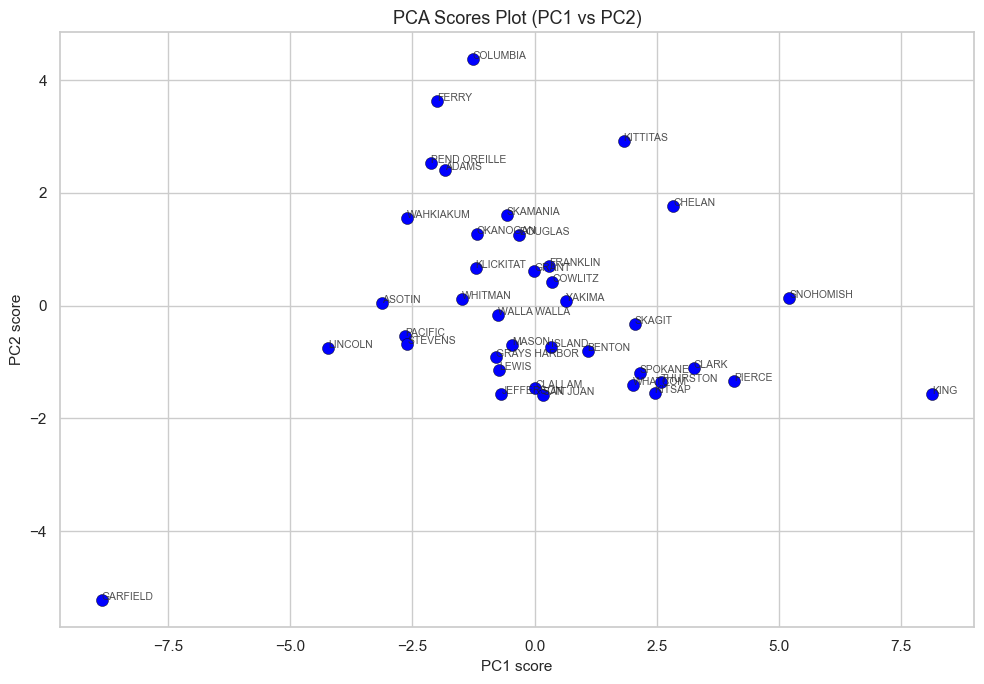

In [8]:
# PC1 vs PC2 scatter with county labels
plt.figure(figsize=(10, 7))
sns.scatterplot(data=my_scores, x='PC1', y='PC2', s=75, color='blue', edgecolor='black', linewidth=0.3)

for _, row in my_scores.iterrows():
    plt.text(row['PC1'], row['PC2'], row['county'], fontsize=7.5, alpha=0.8)

plt.title('PCA Scores Plot (PC1 vs PC2)', fontsize=13)
plt.xlabel('PC1 score', fontsize=11)
plt.ylabel('PC2 score', fontsize=11)
plt.tight_layout()
plt.show()

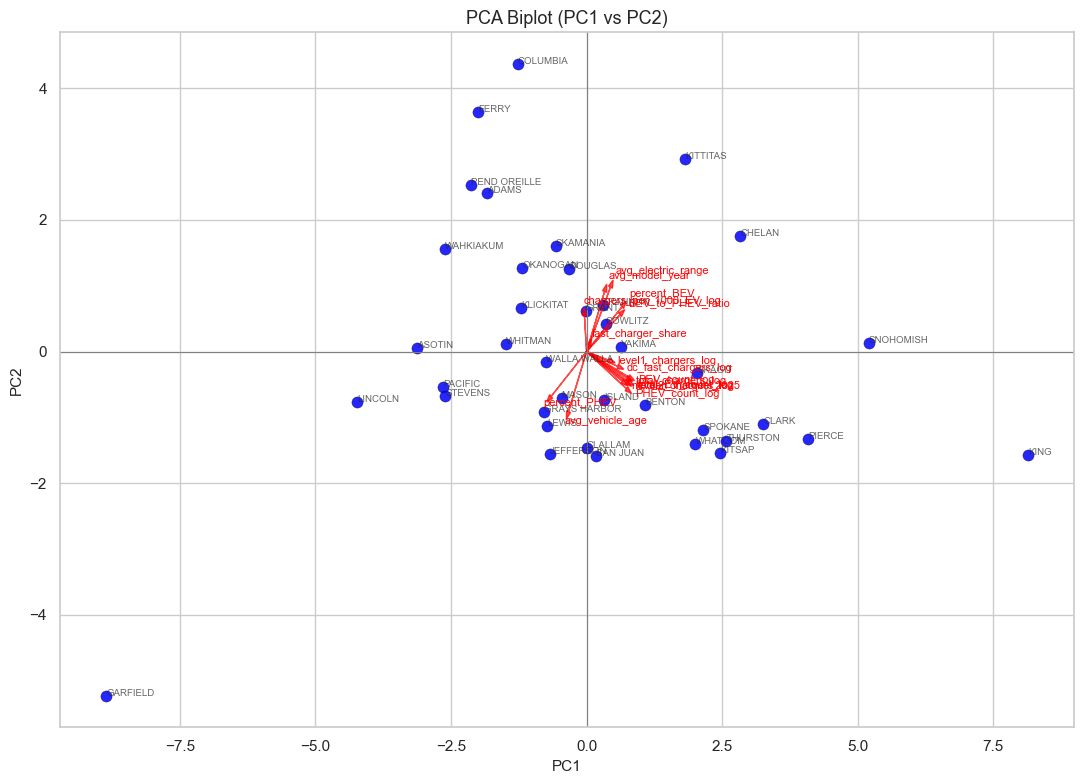

In [9]:
# PCA biplot with scores and arrows
# Scale arrows to match score spread so they are readable and proportional.
my_score_x = my_scores['PC1']
my_score_y = my_scores['PC2']
my_load_x = my_loadings['PC1']
my_load_y = my_loadings['PC2']

my_x_scale = (my_score_x.max() - my_score_x.min()) / max(1e-9, (my_load_x.max() - my_load_x.min()))
my_y_scale = (my_score_y.max() - my_score_y.min()) / max(1e-9, (my_load_y.max() - my_load_y.min()))
my_biplot_scale = 0.22 * min(my_x_scale, my_y_scale)

plt.figure(figsize=(11, 8))
sns.scatterplot(data=my_scores, x='PC1', y='PC2', s=65, color='blue', alpha=0.85, edgecolor='black', linewidth=0.25)

for _, row in my_scores.iterrows():
    plt.text(row['PC1'], row['PC2'], row['county'], fontsize=7, alpha=0.7)

for feat in my_X.columns:
    x_arrow = my_loadings.loc[feat, 'PC1'] * my_biplot_scale
    y_arrow = my_loadings.loc[feat, 'PC2'] * my_biplot_scale
    plt.arrow(0, 0, x_arrow, y_arrow, color='red', alpha=0.7, head_width=0.08, length_includes_head=True)
    plt.text(x_arrow * 1.08, y_arrow * 1.08, feat, color='red', fontsize=8)

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('PCA Biplot (PC1 vs PC2)', fontsize=13)
plt.xlabel('PC1', fontsize=11)
plt.ylabel('PC2', fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# View: top +/- loadings for first 3 PCs
for pc in ['PC1', 'PC2', 'PC3']:
    print(f'\nTop loadings for {pc}')
    
    pc_sorted = my_loadings[pc].sort_values()
    df = pd.concat([
        pc_sorted.head(5).rename('most_negative'),
        pc_sorted.tail(5).rename('most_positive')
    ], axis=1)
    
    # Format only float columns
    float_cols = df.select_dtypes(include='float').columns
    display(df.style.format({col: "{:.4f}" for col in float_cols}))


Top loadings for PC1


,most_negative,most_positive
percent_PHEV,-0.2767,nan
avg_vehicle_age,-0.1403,nan
chargers_per_1000_EV_log,-0.0180,nan
fast_charger_share,0.0355,nan
avg_model_year,0.1403,nan
PHEV_count_log,nan,0.3120
level2_chargers_log,nan,0.3126
total_chargers_log,nan,0.3186
total_EV_count_log,nan,0.3271
BEV_count_log,nan,0.3330



Top loadings for PC2


,most_negative,most_positive
avg_vehicle_age,-0.3851,nan
percent_PHEV,-0.2885,nan
PHEV_count_log,-0.2395,nan
level2_chargers_log,-0.1990,nan
median_income_2025,-0.1946,nan
BEV_to_PHEV_ratio,nan,0.2397
chargers_per_1000_EV_log,nan,0.2511
percent_BEV,nan,0.2882
avg_model_year,nan,0.3851
avg_electric_range,nan,0.4086



Top loadings for PC3


,most_negative,most_positive
avg_electric_range,-0.2508,nan
BEV_to_PHEV_ratio,-0.2472,nan
avg_vehicle_age,-0.2436,nan
percent_BEV,-0.1928,nan
median_income_2025,-0.1545,nan
total_chargers_log,nan,0.1957
avg_model_year,nan,0.2436
dc_fast_chargers_log,nan,0.3700
chargers_per_1000_EV_log,nan,0.4289
fast_charger_share,nan,0.5393


### 1) PCA Interpretation Notes

#### `EV_project_PCA_A`
- **Interpretation depth:** Clear narrative for `PC1`–`PC3`. Full variance table is present, but interpretation focuses on the first three components.
- **Top loading features**
  - **PC1 positive:** `BEV_count_log`, `total_EV_count_log`, `total_chargers_log`, `level2_chargers_log`, `PHEV_count_log`
  - **PC1 negative:** `percent_PHEV`, `avg_vehicle_age`
  - **PC2 positive:** `avg_electric_range`, `avg_model_year`, `percent_BEV`, `chargers_per_1000_EV_log`, `BEV_to_PHEV_ratio`
  - **PC2 negative:** `avg_vehicle_age`, `percent_PHEV`, `PHEV_count_log`, `level2_chargers_log`, `median_income_2025`
  - **PC3 positive:** `fast_charger_share`, `chargers_per_1000_EV_log`, `dc_fast_chargers_log`, `avg_model_year`
  - **PC3 negative:** `avg_electric_range`, `BEV_to_PHEV_ratio`, `avg_vehicle_age`, `percent_BEV`, `median_income_2025`
- **Extreme counties**
  - `GARFIELD` is the strongest outlier (singleton cluster; largest SVD magnitudes).
  - `KING` and metro counties (`SNOHOMISH`, `PIERCE`, `CLARK`) sit at the high‑adoption end.
  - Additional directional counties include `ADAMS`, `COLUMBIA`, `FERRY`, `ASOTIN`.
- **EV story by component**
  - **PC1:** EV ecosystem scale (EV volume + charging buildout).
  - **PC2:** Modernization axis (newer, longer‑range, BEV‑leaning vs older/PHEV‑heavy).
  - **PC3:** Charging mix/intensity (fast‑charging share vs range/BEV‑ratio structure).

#### `EV_project_PCA_G`
- **Top loading features:** Same pattern as A (nearly identical coefficients).
- **Extreme counties**
  - `KING` appears at the high‑adoption extreme.
  - `GARFIELD` is again the clear outlier.
  - Directional examples include `ADAMS`, `CHELAN`, `ASOTIN`, `CLALLAM`.
- **EV story:** Same as A — PC1 = scale/infrastructure, PC2 = modernization/BEV tilt, PC3 = charging‑structure axis.

#### `EV_Project_PCA_N`
- **Top loading features:** Matches A and G.
- **Extreme counties**
  - `GARFIELD` remains the extreme outlier.
  - Metro/high‑adoption counties (`KING` and nearby large counties`) sit on the EV‑forward side.
- **EV story:** Same three‑axis interpretation as A and G.

### B. SVD

U shape: (39, 16)
Sigma shape: (16,)
V* shape: (16, 16)


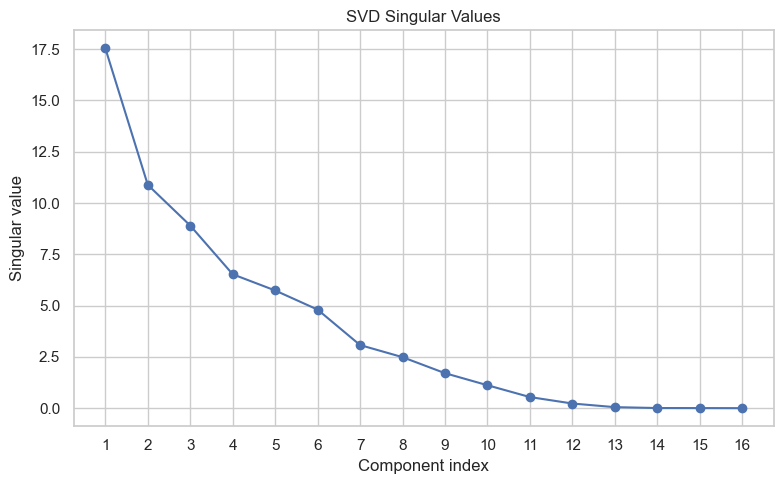

In [11]:
# SVD numeric matrix
my_U, my_singular_values, my_Vt = np.linalg.svd(my_X.values, full_matrices=False)

print('U shape:', my_U.shape)
print('Sigma shape:', my_singular_values.shape)
print('V* shape:', my_Vt.shape)

# Plot singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(my_singular_values) + 1), my_singular_values, marker='o')
plt.title('SVD Singular Values')
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.xticks(range(1, len(my_singular_values) + 1))
plt.tight_layout()
plt.show()

In [12]:
# Put U and V* into readable tables
my_U_df = pd.DataFrame(my_U, index=my_county_names, columns=[f'U{i+1}' for i in range(my_U.shape[1])])
my_Vt_df = pd.DataFrame(my_Vt, columns=my_X.columns, index=[f'V{i+1}' for i in range(my_Vt.shape[0])])

print('U matrix (first 10 counties, first 5 columns):')
display(my_U_df.iloc[:10, :5])

print('V* matrix (first 5 rows, first 10 features):')
display(my_Vt_df.iloc[:5, :10])

U matrix (first 10 counties, first 5 columns):


,U1,U2,U3,U4,U5
county,,,,,
ADAMS,0.104535,0.220673,0.240299,0.296177,-0.077748
ASOTIN,0.178249,0.004780,-0.094924,-0.079056,0.020230
BENTON,-0.061944,-0.074216,0.025676,-0.052026,-0.165666
CHELAN,-0.161585,0.161901,-0.000863,0.145882,0.317742
CLALLAM,-0.000421,-0.134795,0.086903,0.150956,-0.003273
CLARK,-0.185888,-0.101119,0.060035,-0.095582,-0.203226
COLUMBIA,0.072492,0.401303,-0.058321,0.298001,0.279189
COWLITZ,-0.020397,0.038473,0.133411,0.063361,-0.189312
DOUGLAS,0.018230,0.114603,-0.160449,0.015429,-0.112715


V* matrix (first 5 rows, first 10 features):


,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,fast_charger_share,total_EV_count_log,BEV_count_log
V1,-0.140318,-0.184324,0.140318,-0.277103,0.276719,-0.265153,-0.283795,-0.035470,-0.327118,-0.332953
V2,0.385080,0.408595,-0.385080,0.288189,-0.288545,0.239750,-0.194603,0.074574,-0.194118,-0.166055
V3,0.243554,-0.250759,-0.243554,-0.192814,0.193444,-0.247237,-0.154500,0.539276,0.026663,0.014648
V4,-0.487684,0.169475,0.487684,0.145373,-0.145559,0.298197,-0.007754,0.459353,-0.099508,-0.089433
V5,-0.019501,-0.023414,0.019501,-0.100020,0.101732,0.016021,-0.108048,-0.312075,-0.120548,-0.123986


In [13]:
# Dominant counties and features by first 2 singular vectors
for vec in ['U1', 'U2']:
    print(f'\nCounties with largest magnitude in {vec}:')
    display(my_U_df[vec].abs().sort_values(ascending=False).head(10).to_frame('abs_weight'))

for vec in ['V1', 'V2']:
    print(f'\nFeatures with largest magnitude in {vec}:')
    display(my_Vt_df.loc[vec].abs().sort_values(ascending=False).head(10).to_frame('abs_weight'))


Counties with largest magnitude in U1:


,abs_weight
county,
GARFIELD,0.505121
KING,0.464099
SNOHOMISH,0.296836
LINCOLN,0.240944
PIERCE,0.233101
CLARK,0.185888
ASOTIN,0.178249
CHELAN,0.161585
PACIFIC,0.151124



Counties with largest magnitude in U2:


,abs_weight
county,
GARFIELD,0.480148
COLUMBIA,0.401303
FERRY,0.333728
KITTITAS,0.268201
PEND OREILLE,0.232039
ADAMS,0.220673
CHELAN,0.161901
SKAMANIA,0.147004
SAN JUAN,0.145246



Features with largest magnitude in V1:


,abs_weight
BEV_count_log,0.332953
total_EV_count_log,0.327118
total_chargers_log,0.318603
level2_chargers_log,0.312631
PHEV_count_log,0.312035
median_income_2025,0.283795
percent_BEV,0.277103
percent_PHEV,0.276719
BEV_to_PHEV_ratio,0.265153
dc_fast_chargers_log,0.258240



Features with largest magnitude in V2:


,abs_weight
avg_electric_range,0.408595
avg_model_year,0.385080
avg_vehicle_age,0.385080
percent_PHEV,0.288545
percent_BEV,0.288189
chargers_per_1000_EV_log,0.251092
BEV_to_PHEV_ratio,0.239750
PHEV_count_log,0.239461
level2_chargers_log,0.199001
median_income_2025,0.194603


In [14]:
# Compare PCA and SVD directions
my_svd_feature_vectors = my_Vt_df.T.copy()

my_sign_v1 = np.sign((my_loadings['PC1'] * my_svd_feature_vectors['V1']).sum())
my_sign_v2 = np.sign((my_loadings['PC2'] * my_svd_feature_vectors['V2']).sum())
my_sign_v1 = 1 if my_sign_v1 == 0 else my_sign_v1
my_sign_v2 = 1 if my_sign_v2 == 0 else my_sign_v2

my_v1_aligned = my_svd_feature_vectors['V1'] * my_sign_v1
my_v2_aligned = my_svd_feature_vectors['V2'] * my_sign_v2

my_compare_pc1_v1_corr = np.corrcoef(my_loadings['PC1'], my_v1_aligned)[0, 1]
my_compare_pc2_v2_corr = np.corrcoef(my_loadings['PC2'], my_v2_aligned)[0, 1]

print('\nPCA vs SVD direction agreement (after sign alignment):')
print(f'corr(PC1 loadings, aligned V1) = {my_compare_pc1_v1_corr:.4f}')
print(f'corr(PC2 loadings, aligned V2) = {my_compare_pc2_v2_corr:.4f}')

my_pca_svd_compare = pd.DataFrame({
    'PC1_loading': my_loadings['PC1'],
    'aligned_V1_weight': my_v1_aligned,
    'PC2_loading': my_loadings['PC2'],
    'aligned_V2_weight': my_v2_aligned
}, index=my_X.columns)

print('\nFeature-by-feature PCA/SVD comparison (first 12 features):')
display(my_pca_svd_compare.head(12))


PCA vs SVD direction agreement (after sign alignment):
corr(PC1 loadings, aligned V1) = 1.0000
corr(PC2 loadings, aligned V2) = 1.0000

Feature-by-feature PCA/SVD comparison (first 12 features):


,PC1_loading,aligned_V1_weight,PC2_loading,aligned_V2_weight
avg_model_year,0.140318,0.140318,0.385080,0.385080
avg_electric_range,0.184324,0.184324,0.408595,0.408595
avg_vehicle_age,-0.140318,-0.140318,-0.385080,-0.385080
percent_BEV,0.277103,0.277103,0.288189,0.288189
percent_PHEV,-0.276719,-0.276719,-0.288545,-0.288545
BEV_to_PHEV_ratio,0.265153,0.265153,0.239750,0.239750
median_income_2025,0.283795,0.283795,-0.194603,-0.194603
fast_charger_share,0.035470,0.035470,0.074574,0.074574
total_EV_count_log,0.327118,0.327118,-0.194118,-0.194118
BEV_count_log,0.332953,0.332953,-0.166055,-0.166055


### 2) SVD Interpretation Notes

- **Only `EV_project_PCA_A` includes SVD.**
- **U (county positions):** Largest |U1|/|U2| values occur for `GARFIELD`, `KING`, `SNOHOMISH`, `COLUMBIA`, `FERRY`.
- **V (feature directions):**
  - `V1` dominated by EV count and charger log features.
  - `V2` reflects the range/model‑year vs age/PHEV contrast.
- **PCA vs SVD consistency:** Perfect alignment after sign correction (`corr(PC1,V1)=1.000`, `corr(PC2,V2)=1.000`).

## 3. K-Means Clustering

C:\Users\alexm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alexm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\alexm\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alexm\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

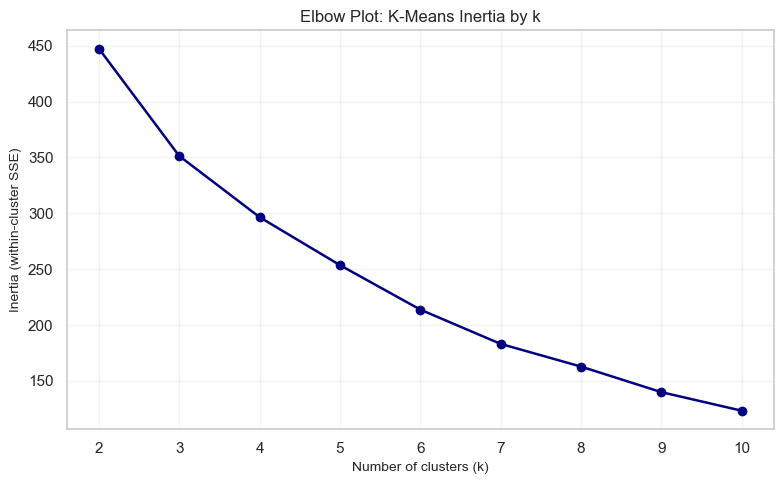

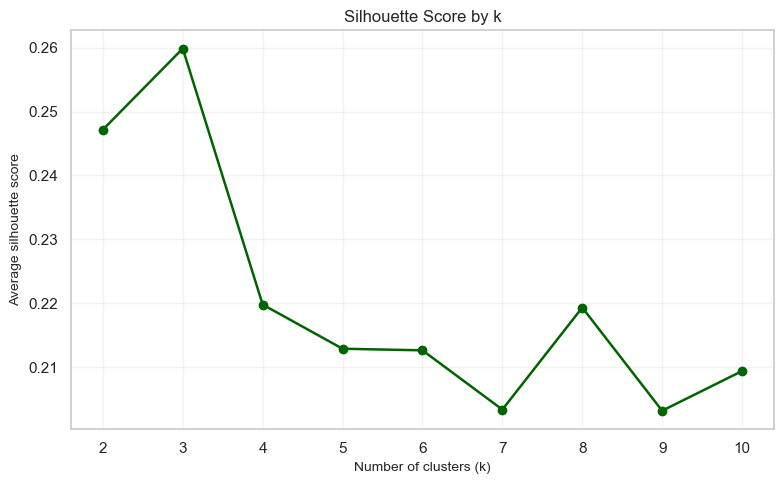

In [15]:
# Elbow scan: k = 2..10
my_k_values = list(range(2, 11))
my_inertia = []
my_silhouette = []

for k in my_k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(my_X)
    my_inertia.append(km.inertia_)
    my_silhouette.append(silhouette_score(my_X, labels))

plt.figure(figsize=(8, 5))
plt.plot(my_k_values, my_inertia, marker='o', linewidth=1.8, color='navy')
plt.title('Elbow Plot: K-Means Inertia by k', fontsize=12)
plt.xlabel('Number of clusters (k)', fontsize=10)
plt.ylabel('Inertia (within-cluster SSE)', fontsize=10)
plt.xticks(my_k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(my_k_values, my_silhouette, marker='o', linewidth=1.8, color='darkgreen')
plt.title('Silhouette Score by k', fontsize=12)
plt.xlabel('Number of clusters (k)', fontsize=10)
plt.ylabel('Average silhouette score', fontsize=10)
plt.xticks(my_k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [16]:
my_k_diagnostics = pd.DataFrame({'k': my_k_values, 'inertia': my_inertia, 'silhouette': my_silhouette})
print('K-means diagnostics table:')
display(my_k_diagnostics)

K-means diagnostics table:


,k,inertia,silhouette
0,2,447.478669,0.247166
1,3,351.358202,0.259849
2,4,296.606159,0.219822
3,5,253.642350,0.212920
4,6,213.852169,0.212669
5,7,183.167415,0.203409
6,8,162.851863,0.219357
7,9,139.973530,0.203228
8,10,123.376091,0.209431


Final cluster assignments:


C:\Users\alexm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,county,kmeans_cluster
3,CHELAN,0
2,BENTON,0
5,CLARK,0
28,SKAGIT,0
26,PIERCE,0
31,SPOKANE,0
17,KITSAP,0
16,KING,0
30,SNOHOMISH,0
33,THURSTON,0


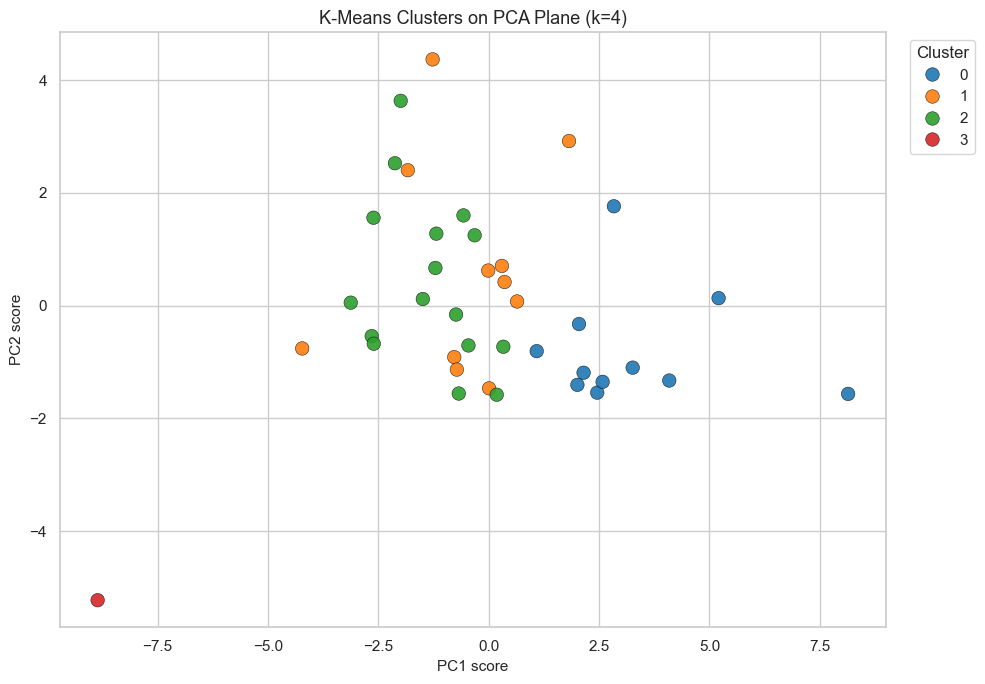

In [17]:
# Pick final k (change if you want after inspecting elbow/silhouette)
my_k_final = 4

my_kmeans = KMeans(n_clusters=my_k_final, random_state=42, n_init=20)
my_cluster_labels = my_kmeans.fit_predict(my_X)

my_clustered = my_scores.copy()
my_clustered['cluster'] = my_cluster_labels

# Final cluster assignments
my_assignments = pd.DataFrame({'county': my_county_names, 'kmeans_cluster': my_cluster_labels})
print('Final cluster assignments:')
display(my_assignments.sort_values('kmeans_cluster'))

# Cleaner PCA-plane view for clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=my_clustered,
    x='PC1', y='PC2',
    hue='cluster', palette='tab10',
    s=95, edgecolor='black', linewidth=0.35, alpha=0.9
)
plt.title(f'K-Means Clusters on PCA Plane (k={my_k_final})', fontsize=13)
plt.xlabel('PC1 score', fontsize=11)
plt.ylabel('PC2 score', fontsize=11)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [18]:
# Cluster centroids in scaled space
my_centroids = pd.DataFrame(my_kmeans.cluster_centers_, columns=my_X.columns)
my_centroids.index = [f'cluster_{i}' for i in range(my_k_final)]
print('Cluster centroids (scaled feature space):')
display(my_centroids)

# Cluster-level feature means from the original matrix
my_X_with_cluster = my_X.copy()
my_X_with_cluster['cluster'] = my_cluster_labels
my_cluster_means = my_X_with_cluster.groupby('cluster').mean()

print('Cluster-level feature means:')
display(my_cluster_means)

print('Counties per cluster:')
my_counties_per_cluster = my_assignments.groupby('kmeans_cluster')['county'].apply(list)
display(my_counties_per_cluster.to_frame('counties'))

Cluster centroids (scaled feature space):


,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,fast_charger_share,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
cluster_0,0.214135,0.281548,-0.214135,0.616489,-0.613571,0.709684,1.213270,0.004366,1.160815,1.153676,1.145241,1.157585,0.689569,1.184346,1.045971,-0.342761
cluster_1,0.146320,-0.025777,-0.146320,-0.095127,0.095999,-0.151585,-0.550624,1.230091,-0.300201,-0.292873,-0.301305,0.020251,-0.354030,-0.368477,0.520226,0.910762
cluster_2,-0.016124,0.014603,0.016124,-0.094397,0.091906,-0.229926,-0.402654,-0.795614,-0.433865,-0.419940,-0.439183,-0.679060,-0.208557,-0.447317,-1.008063,-0.255179
cluster_3,-3.707016,-3.047131,3.707016,-4.224637,4.222797,-2.460278,-0.846648,-0.849210,-2.524911,-2.749797,-2.256353,-2.091232,-0.354030,-1.817486,-1.099162,-2.165150


Cluster-level feature means:


,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,fast_charger_share,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
cluster,,,,,,,,,,,,,,,,
0,0.214135,0.281548,-0.214135,0.616489,-0.613571,0.709684,1.213270,0.004366,1.160815,1.153676,1.145241,1.157585,0.689569,1.184346,1.045971,-0.342761
1,0.146320,-0.025777,-0.146320,-0.095127,0.095999,-0.151585,-0.550624,1.230091,-0.300201,-0.292873,-0.301305,0.020251,-0.354030,-0.368477,0.520226,0.910762
2,-0.016124,0.014603,0.016124,-0.094397,0.091906,-0.229926,-0.402654,-0.795614,-0.433865,-0.419940,-0.439183,-0.679060,-0.208557,-0.447317,-1.008063,-0.255179
3,-3.707016,-3.047131,3.707016,-4.224637,4.222797,-2.460278,-0.846648,-0.849210,-2.524911,-2.749797,-2.256353,-2.091232,-0.354030,-1.817486,-1.099162,-2.165150


Counties per cluster:


,counties
kmeans_cluster,
0,"[BENTON, CHELAN, CLARK, KING, KITSAP, PIERCE, ..."
1,"[ADAMS, CLALLAM, COLUMBIA, COWLITZ, FRANKLIN, ..."
2,"[ASOTIN, DOUGLAS, FERRY, ISLAND, JEFFERSON, KL..."
3,[GARFIELD]


### 3) K‑Means Interpretation Notes

#### `EV_project_PCA_A` (`k=4`)
- Cluster sizes: `11`, `11`, `16`, `1`.
- `GARFIELD` forms a singleton outlier cluster.
- One cluster is metro/high‑EV (`KING`, `SNOHOMISH`, `PIERCE`, `CLARK`, `SPOKANE`, etc.).
- Compared with G/N, A splits the broad rural/mid‑low group into **two** clusters (11 + 16), giving finer segmentation.

#### `EV_project_PCA_G` (`k=3`)
- Cluster sizes: `11`, `27`, `1`.
- **High‑intensity cluster (11 counties):** high EV counts, chargers, income, BEV share.
- **Broad baseline cluster (27 counties):** lower EV scale but higher chargers‑per‑1000‑EV.
- **Singleton outlier:** `GARFIELD`.

#### `EV_Project_PCA_N` (`k=3`)
- Same cluster sizes and membership as G.
- Same interpretation: metro EV‑heavy group, broad lower‑scale group, and `GARFIELD` as the outlier.

## 4. Hierarchical Clustering

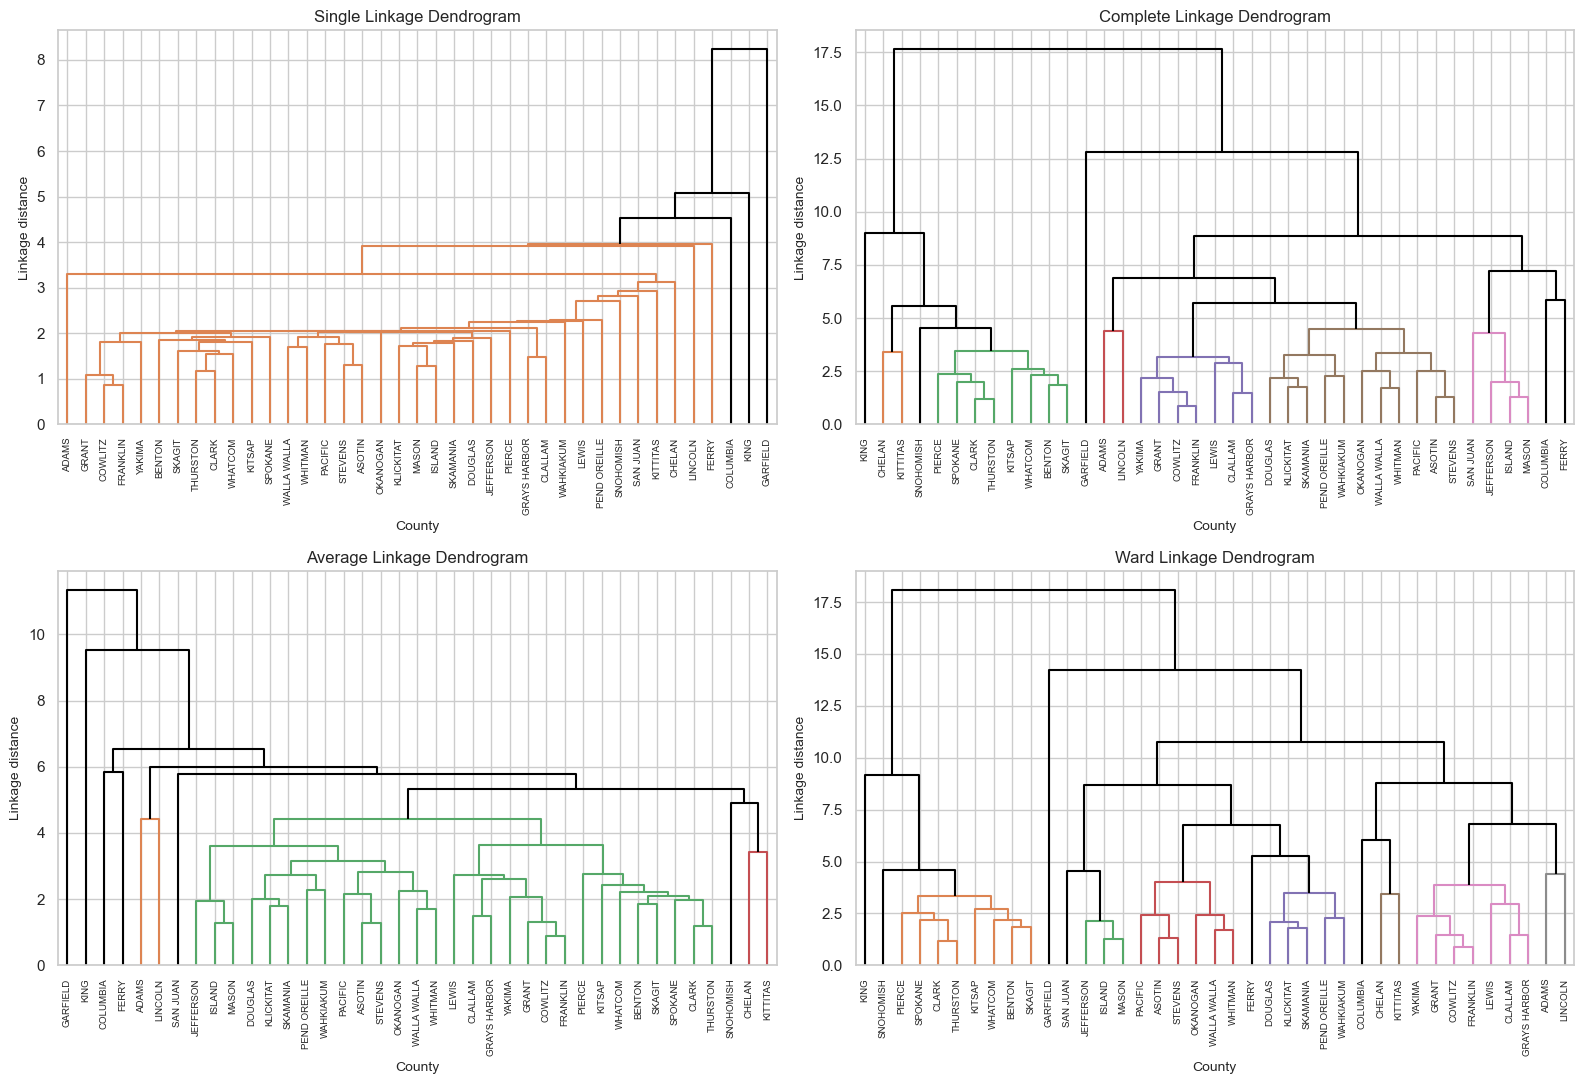

In [19]:
# Hierarchical using AgglomerativeClustering and compute_linkage
my_link_methods = ['single', 'complete', 'average', 'ward']
my_hc_full_models = {}
my_linkage_mats = {}

for method in my_link_methods:
    if method == 'ward':
        model = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=0,
            compute_distances=True,
            linkage=method
        ).fit(my_X)
    else:
        try:
            model = AgglomerativeClustering(
                n_clusters=None,
                distance_threshold=0,
                compute_distances=True,
                linkage=method,
                metric='euclidean'
            ).fit(my_X)
        except TypeError:
            model = AgglomerativeClustering(
                n_clusters=None,
                distance_threshold=0,
                compute_distances=True,
                linkage=method,
                affinity='euclidean'
            ).fit(my_X)

    my_hc_full_models[method] = model
    my_linkage_mats[method] = compute_linkage(model)

# Color branches using a finite cut
my_color_cut = np.percentile(my_linkage_mats['ward'][:, 2], 70)
cargs = {'color_threshold': my_color_cut, 'above_threshold_color': 'black'}

# Plot 4 dendrograms with readable county labels
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, method in zip(axes, my_link_methods):
    dendrogram(
        my_linkage_mats[method],
        labels=my_county_names.values,
        leaf_rotation=90,
        leaf_font_size=7,
        ax=ax,
        **cargs
    )
    ax.set_title(f'{method.title()} Linkage Dendrogram', fontsize=12)
    ax.set_xlabel('County', fontsize=10)
    ax.set_ylabel('Linkage distance', fontsize=10)

plt.tight_layout()
plt.show()

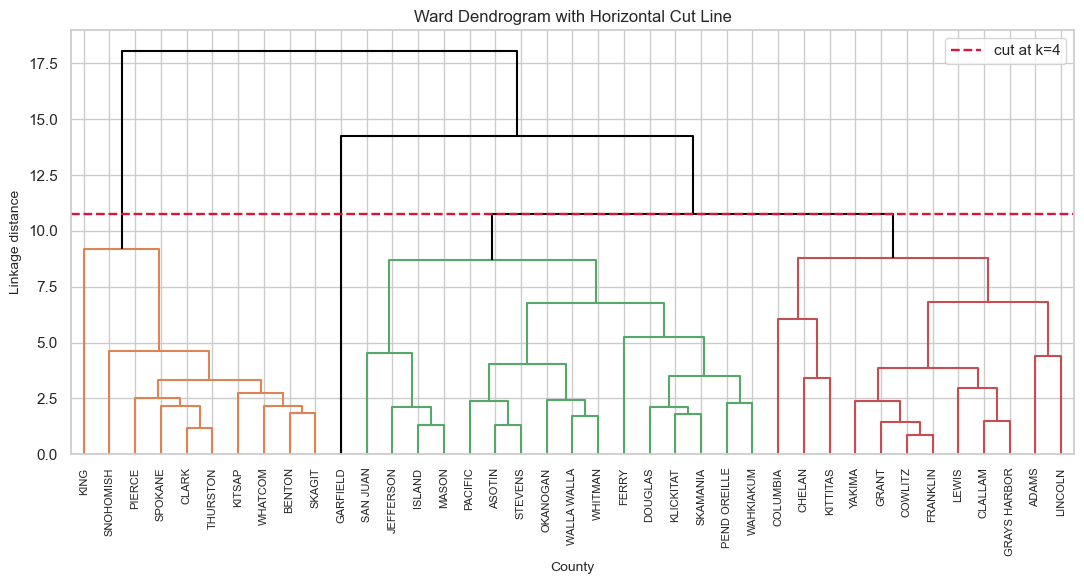

In [20]:
# Cut-tree example and cluster membership comparison
my_k_hc = 4

# cut_tree on each linkage matrix
my_cut_tree_labels = {}
for method in my_link_methods:
    my_cut_tree_labels[method] = cut_tree(my_linkage_mats[method], n_clusters=my_k_hc).reshape(-1)

# Add a horizontal cut line on Ward dendrogram
plt.figure(figsize=(11, 6))
my_ward_link = my_linkage_mats['ward']
my_cut_height = my_ward_link[-(my_k_hc - 1), 2] if my_k_hc > 1 else my_ward_link[-1, 2]

dendrogram(
    my_ward_link,
    labels=my_county_names.values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=my_cut_height,
    above_threshold_color='black'
)
plt.axhline(y=my_cut_height, color='crimson', linestyle='--', linewidth=1.7, label=f'cut at k={my_k_hc}')
plt.title('Ward Dendrogram with Horizontal Cut Line', fontsize=12)
plt.xlabel('County', fontsize=10)
plt.ylabel('Linkage distance', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [21]:
# Fit AgglomerativeClustering directly at fixed k for each method
my_hc_labels = {}
for method in my_link_methods:
    if method == 'ward':
        model_k = AgglomerativeClustering(n_clusters=my_k_hc, linkage=method)
    else:
        try:
            model_k = AgglomerativeClustering(n_clusters=my_k_hc, linkage=method, metric='euclidean')
        except TypeError:
            model_k = AgglomerativeClustering(n_clusters=my_k_hc, linkage=method, affinity='euclidean')
    my_hc_labels[method] = model_k.fit_predict(my_X)

my_hc_compare = pd.DataFrame({'county': my_county_names, 'kmeans_cluster': my_cluster_labels})
for method in my_link_methods:
    my_hc_compare[f'hc_{method}'] = my_hc_labels[method]
    my_hc_compare[f'cut_tree_{method}'] = my_cut_tree_labels[method]

print('Cluster assignments (K-means vs hierarchical):')
display(my_hc_compare.sort_values('kmeans_cluster'))

for method in my_link_methods:
    print(f'\nCrosstab: K-means vs {method.title()} linkage')
    display(pd.crosstab(my_hc_compare['kmeans_cluster'], my_hc_compare[f'hc_{method}']))

Cluster assignments (K-means vs hierarchical):


,county,kmeans_cluster,hc_single,cut_tree_single,hc_complete,cut_tree_complete,hc_average,cut_tree_average,hc_ward,cut_tree_ward
3,CHELAN,0,0,0,1,1,0,0,1,0
2,BENTON,0,0,0,1,1,0,0,0,2
5,CLARK,0,0,0,1,1,0,0,0,2
28,SKAGIT,0,0,0,1,1,0,0,0,2
26,PIERCE,0,0,0,1,1,0,0,0,2
31,SPOKANE,0,0,0,1,1,0,0,0,2
17,KITSAP,0,0,0,1,1,0,0,0,2
16,KING,0,2,3,3,3,2,3,0,2
30,SNOHOMISH,0,0,0,1,1,0,0,0,2
33,THURSTON,0,0,0,1,1,0,0,0,2



Crosstab: K-means vs Single linkage


hc_single,0,1,2,3
kmeans_cluster,,,,
0,10,0,1,0
1,10,0,0,1
2,16,0,0,0
3,0,1,0,0



Crosstab: K-means vs Complete linkage


hc_complete,0,1,2,3
kmeans_cluster,,,,
0,0,10,0,1
1,10,1,0,0
2,16,0,0,0
3,0,0,1,0



Crosstab: K-means vs Average linkage


hc_average,0,1,2,3
kmeans_cluster,,,,
0,10,0,1,0
1,10,1,0,0
2,15,1,0,0
3,0,0,0,1



Crosstab: K-means vs Ward linkage


hc_ward,0,1,2,3
kmeans_cluster,,,,
0,10,1,0,0
1,0,11,0,0
2,0,0,0,16
3,0,0,1,0


### 4) Hierarchical Clustering Interpretation Notes

#### `EV_project_PCA_A`
- Includes `single`, `complete`, `average`, and `ward` linkage.
- **ARI vs K‑means:**
  - `ward`: **0.934**
  - `complete`: **0.492**
  - `single`: **0.062**
  - `average`: **0.044**
- Stable signals: `GARFIELD` always isolated; metro core stays grouped under Ward/complete.

#### `EV_project_PCA_G`
- Uses **Ward** linkage.
- K‑means vs Ward ARI: **0.900**.

#### `EV_Project_PCA_N`
- Shows Ward + Complete dendrograms.
- Ward ARI vs K‑means: **0.900**.
- Complete linkage shown visually only.